# 01 · Data Exploration
**RavenStack SaaS dataset (synthetic, by River @ Rivalytics).** Before any analysis is designed, this notebook
inspects every raw file: schema, row counts, keys, missing values, duplicates, date ranges, categorical domains and
the relationships between tables. Nothing here modifies data.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60, "display.width", 200, "display.float_format", "{:,.4f}".format)

from src.data.clean import read_raw
TABLES = ["accounts", "subscriptions", "feature_usage", "support_tickets", "churn_events"]
raw = {name: read_raw(name) for name in TABLES}
pd.DataFrame({name: {"rows": df.shape[0], "columns": df.shape[1]} for name, df in raw.items()}).T

,rows,columns
accounts,500,10
subscriptions,5000,14
feature_usage,25000,8
support_tickets,2000,9
churn_events,600,9


## 1. Column profile per table

In [2]:
def profile(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulls": df.isna().sum(),
        "null_pct": (100 * df.isna().mean()).round(2),
        "unique": df.nunique(),
        "example": df.apply(lambda s: s.dropna().iloc[0] if s.notna().any() else None),
    })

for name, df in raw.items():
    display(Markdown(f"### {name} ({len(df):,} rows)"))
    display(profile(df))

### accounts (500 rows)

,dtype,nulls,null_pct,unique,example
account_id,str,0,0.0000,500,A-2e4581
account_name,str,0,0.0000,500,Company_0
industry,str,0,0.0000,5,EdTech
country,str,0,0.0000,7,US
signup_date,str,0,0.0000,370,2024-10-16
referral_source,str,0,0.0000,5,partner
plan_tier,str,0,0.0000,3,Basic
seats,int64,0,0.0000,73,9
is_trial,bool,0,0.0000,2,False
churn_flag,bool,0,0.0000,2,False


### subscriptions (5,000 rows)

,dtype,nulls,null_pct,unique,example
subscription_id,str,0,0.0000,5000,S-8cec59
account_id,str,0,0.0000,500,A-3c1a3f
start_date,str,0,0.0000,625,2023-12-23
end_date,str,4514,90.2800,208,2024-04-12
plan_tier,str,0,0.0000,3,Enterprise
seats,int64,0,0.0000,123,14
mrr_amount,int64,0,0.0000,306,2786
arr_amount,int64,0,0.0000,306,33432
is_trial,bool,0,0.0000,2,False
upgrade_flag,bool,0,0.0000,2,False


### feature_usage (25,000 rows)

,dtype,nulls,null_pct,unique,example
usage_id,str,0,0.0000,24979,U-1c6c24
subscription_id,str,0,0.0000,4967,S-0fcf7d
usage_date,str,0,0.0000,731,2023-07-27
feature_name,str,0,0.0000,40,feature_20
usage_count,int64,0,0.0000,27,9
usage_duration_secs,int64,0,0.0000,4168,5004
error_count,int64,0,0.0000,9,0
is_beta_feature,bool,0,0.0000,2,False


### support_tickets (2,000 rows)

,dtype,nulls,null_pct,unique,example
ticket_id,str,0,0.0000,2000,T-0024de
account_id,str,0,0.0000,492,A-712f1c
submitted_at,str,0,0.0000,671,2023-07-27
closed_at,str,0,0.0000,1893,2023-07-28 03:00:00
resolution_time_hours,float64,0,0.0000,72,27.0000
priority,str,0,0.0000,4,high
first_response_time_minutes,int64,0,0.0000,180,74
satisfaction_score,float64,825,41.2500,3,4.0000
escalation_flag,bool,0,0.0000,2,False


### churn_events (600 rows)

,dtype,nulls,null_pct,unique,example
churn_event_id,str,0,0.0000,600,C-816288
account_id,str,0,0.0000,352,A-c37cab
churn_date,str,0,0.0000,311,2024-10-27
reason_code,str,0,0.0000,6,pricing
refund_amount_usd,float64,0,0.0000,142,4.0300
preceding_upgrade_flag,bool,0,0.0000,2,False
preceding_downgrade_flag,bool,0,0.0000,2,False
is_reactivation,bool,0,0.0000,2,False
feedback_text,str,148,24.6700,3,switched to competitor


## 2. Duplicates and candidate keys

In [3]:
keys = {"accounts": "account_id", "subscriptions": "subscription_id", "feature_usage": "usage_id",
        "support_tickets": "ticket_id", "churn_events": "churn_event_id"}
pd.DataFrame([{"table": n, "full_row_duplicates": raw[n].duplicated().sum(), "key": k,
               "duplicate_key_values": raw[n][k].duplicated().sum()} for n, k in keys.items()])

,table,full_row_duplicates,key,duplicate_key_values
0,accounts,0,account_id,0
1,subscriptions,0,subscription_id,0
2,feature_usage,0,usage_id,21
3,support_tickets,0,ticket_id,0
4,churn_events,0,churn_event_id,0


In [4]:
# usage_id is not unique: are the repeated IDs copies of the same record?
fu = raw["feature_usage"]
dup = fu[fu["usage_id"].duplicated(keep=False)].sort_values("usage_id")
print("rows sharing a usage_id:", len(dup), "| identical apart from the id:", fu.drop(columns="usage_id").duplicated().sum())
dup.head(6)

rows sharing a usage_id: 42 | identical apart from the id: 0


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
17533,U-0c9318,S-0ffab0,2024-01-30,feature_11,3,1614,0,False
19294,U-0c9318,S-01b2dc,2023-12-11,feature_9,5,1060,3,False
9626,U-13ce5b,S-8b0950,2024-09-10,feature_9,8,824,0,True
20588,U-13ce5b,S-9b623b,2023-03-26,feature_28,10,2050,1,False
10379,U-2103bb,S-ae3270,2024-01-06,feature_3,10,5510,0,False
18480,U-2103bb,S-7fc49b,2023-04-18,feature_12,9,5022,1,False


## 3. Categorical domains and numeric ranges

In [5]:
for name, df in raw.items():
    for c in df.columns:
        if (df[c].dtype == object or pd.api.types.is_string_dtype(df[c])) and df[c].nunique() <= 10:
            print(f"{name}.{c}: {df[c].value_counts(dropna=False).to_dict()}")

accounts.industry: {'DevTools': 113, 'FinTech': 112, 'Cybersecurity': 100, 'HealthTech': 96, 'EdTech': 79}
accounts.country: {'US': 291, 'UK': 58, 'IN': 49, 'AU': 32, 'DE': 25, 'CA': 23, 'FR': 22}
accounts.referral_source: {'organic': 114, 'other': 103, 'ads': 98, 'event': 96, 'partner': 89}
accounts.plan_tier: {'Pro': 178, 'Basic': 168, 'Enterprise': 154}
subscriptions.plan_tier: {'Enterprise': 1723, 'Pro': 1675, 'Basic': 1602}
subscriptions.billing_frequency: {'monthly': 2539, 'annual': 2461}
support_tickets.priority: {'urgent': 514, 'high': 510, 'medium': 491, 'low': 485}
churn_events.reason_code: {'features': 114, 'support': 104, 'budget': 104, 'unknown': 95, 'competitor': 92, 'pricing': 91}
churn_events.feedback_text: {'too expensive': 161, 'missing features': 155, nan: 148, 'switched to competitor': 136}


In [6]:
pd.concat({n: df.describe().T for n, df in raw.items() if len(df.select_dtypes("number").columns)}, names=["table"])

count        mean         std    min        25%         50%         75%          max
table                                                                                                                                 
accounts        seats                          500.0000     20.5600     21.0447 1.0000     5.0000     15.0000     28.0000     163.0000
subscriptions   seats                        5,000.0000     29.8520     23.0898 1.0000    14.0000     24.0000     40.0000     189.0000
                mrr_amount                   5,000.0000  2,267.7494  3,421.3753 0.0000   285.0000    931.0000  2,786.0000  33,830.0000
                arr_amount                   5,000.0000 27,212.9928 41,056.5042 0.0000 3,420.0000 11,172.0000 33,432.0000 405,960.0000
feature_usage   usage_count                 25,000.0000     10.0210      3.1437 0.0000     8.0000     10.0000     12.0000      26.0000
                usage_duration_secs         25,000.0000  3,042.2029  2,056.5446 0.0000 1,350.0000  2,760.0000  4,400.0000  12,696.0000
                error_count                 25,000.0000      0.5643      1.0126 0.0000     0.0000      0.0000      1.0000       8.0000
support_tickets resolution_time_hours        2,000.0000     35.8610     21.1384 1.0000    17.0000     35.0000     54.0000      72.0000
                first_response_time_minutes  2,000.0000     88.4800     51.5319 1.0000    43.0000     88.0000    131.0000     180.0000
                satisfaction_score           1,175.0000      3.9813      0.8096 3.0000     3.0000      4.0000      5.0000       5.0000
churn_events    refund_amount_usd              600.0000     14.4204     39.2246 0.0000     0.0000      0.0000      0.0000     392.9200

## 4. Date ranges

In [7]:
date_cols = {"accounts": ["signup_date"], "subscriptions": ["start_date", "end_date"], "feature_usage": ["usage_date"],
             "support_tickets": ["submitted_at", "closed_at"], "churn_events": ["churn_date"]}
rows = []
for t, cols in date_cols.items():
    for c in cols:
        d = pd.to_datetime(raw[t][c], errors="coerce")
        rows.append({"column": f"{t}.{c}", "min": d.min(), "max": d.max(), "nulls": d.isna().sum()})
pd.DataFrame(rows)

,column,min,max,nulls
0,accounts.signup_date,2023-01-02 00:00:00,2024-12-31 00:00:00,0
1,subscriptions.start_date,2023-01-09 00:00:00,2024-12-31 00:00:00,0
2,subscriptions.end_date,2023-04-05 00:00:00,2024-12-31 00:00:00,4514
3,feature_usage.usage_date,2023-01-01 00:00:00,2024-12-31 00:00:00,0
4,support_tickets.submitted_at,2023-01-02 00:00:00,2024-12-31 00:00:00,0
5,support_tickets.closed_at,2023-01-03 03:00:00,2024-12-31 19:00:00,0
6,churn_events.churn_date,2023-01-25 00:00:00,2024-12-31 00:00:00,0


## 5. Relationships

In [8]:
acc, sub, tk, ch = raw["accounts"], raw["subscriptions"], raw["support_tickets"], raw["churn_events"]
pd.DataFrame([
    {"relationship": "subscriptions.account_id -> accounts", "orphans": (~sub.account_id.isin(acc.account_id)).sum()},
    {"relationship": "feature_usage.subscription_id -> subscriptions", "orphans": (~fu.subscription_id.isin(sub.subscription_id)).sum()},
    {"relationship": "support_tickets.account_id -> accounts", "orphans": (~tk.account_id.isin(acc.account_id)).sum()},
    {"relationship": "churn_events.account_id -> accounts", "orphans": (~ch.account_id.isin(acc.account_id)).sum()},
])

,relationship,orphans
0,subscriptions.account_id -> accounts,0
1,feature_usage.subscription_id -> subscriptions,0
2,support_tickets.account_id -> accounts,0
3,churn_events.account_id -> accounts,0


In [9]:
print("subscriptions per account:", sub.groupby("account_id").size().describe().round(1).to_dict())
print("churn events per account:", ch.groupby("account_id").size().value_counts().sort_index().to_dict())
print("tickets per account:", tk.groupby("account_id").size().describe().round(1).to_dict())

subscriptions per account: {'count': 500.0, 'mean': 10.0, 'std': 3.3, 'min': 2.0, '25%': 7.0, '50%': 10.0, '75%': 12.0, 'max': 19.0}
churn events per account: {1: 177, 2: 116, 3: 47, 4: 10, 5: 2}
tickets per account: {'count': 492.0, 'mean': 4.1, 'std': 1.8, 'min': 1.0, '25%': 3.0, '50%': 4.0, '75%': 5.0, 'max': 11.0}


## 6. Temporal and logical consistency across tables

In [10]:
a = acc.assign(signup_date=pd.to_datetime(acc.signup_date))
s = sub.assign(start_date=pd.to_datetime(sub.start_date), end_date=pd.to_datetime(sub.end_date))
u = fu.assign(usage_date=pd.to_datetime(fu.usage_date)).merge(s[["subscription_id", "account_id", "start_date", "end_date"]], on="subscription_id") \
      .merge(a[["account_id", "signup_date"]], on="account_id")
t2 = tk.assign(submitted_at=pd.to_datetime(tk.submitted_at)).merge(a[["account_id", "signup_date"]], on="account_id")
pd.DataFrame([
    {"check": "subscription start before signup", "rows": (s.merge(a, on="account_id").eval("start_date < signup_date")).sum(), "of": len(s)},
    {"check": "usage before its subscription start", "rows": (u.usage_date < u.start_date).sum(), "of": len(u)},
    {"check": "usage before account signup", "rows": (u.usage_date < u.signup_date).sum(), "of": len(u)},
    {"check": "ticket before account signup", "rows": (t2.submitted_at < t2.signup_date).sum(), "of": len(t2)},
]).assign(pct=lambda d: (100 * d.rows / d.of).round(1))

,check,rows,of,pct
0,subscription start before signup,0,5000,0.0000
1,usage before its subscription start,19142,25000,76.6000
2,usage before account signup,13198,25000,52.8000
3,ticket before account signup,1077,2000,53.8000


Usage and ticket dates are **not aligned** with account and subscription lifecycles. Subscription dates *are*
consistent with signup dates, so lifecycle analyses (retention, churn timing) use subscription/account/churn
dates, while usage and tickets are used only as lifetime behaviour aggregates.

In [11]:
# Two churn sources: account churn_flag vs presence of churn events
pd.crosstab(acc.churn_flag, acc.account_id.isin(ch.account_id), margins=True).rename_axis(index="churn_flag", columns="has_churn_event")

has_churn_event,False,True,All
churn_flag,,,
False,113,277,390
True,35,75,110
All,148,352,500


In [12]:
# Pricing is deterministic: MRR per seat by plan (paid subscriptions)
paid = sub[~sub.is_trial]
print((paid.mrr_amount / paid.seats).groupby(paid.plan_tier).agg(["min", "max"]))
print("ARR == 12 x MRR:", (sub.arr_amount == 12 * sub.mrr_amount).all(), "| trial subscriptions with MRR > 0:", (sub.is_trial & (sub.mrr_amount > 0)).sum())

                min      max
plan_tier                   
Basic       19.0000  19.0000
Enterprise 199.0000 199.0000
Pro         49.0000  49.0000
ARR == 12 x MRR: True | trial subscriptions with MRR > 0: 0


In [13]:
# accounts.plan_tier vs subscription history
first = s.sort_values("start_date").groupby("account_id").first()
print("accounts.plan_tier == first subscription plan:", round((first.plan_tier == acc.set_index("account_id").plan_tier.reindex(first.index)).mean(), 3))
print("churn_flag=TRUE accounts that still hold an active subscription:",
      acc[acc.churn_flag].account_id.isin(sub[sub.end_date.isna()].account_id).sum(), "of", acc.churn_flag.sum())

accounts.plan_tier == first subscription plan: 0.33
churn_flag=TRUE accounts that still hold an active subscription: 110 of 110


## 7. Volume over time

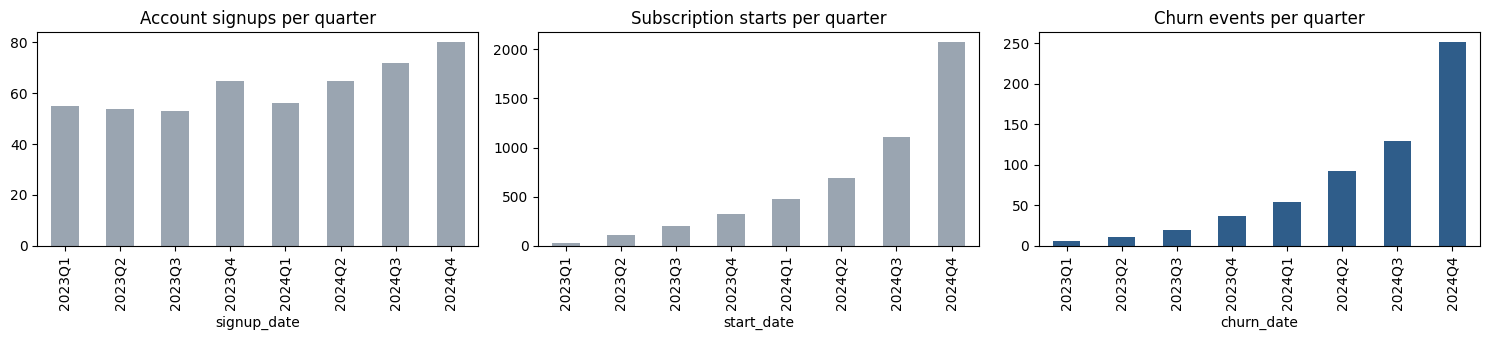

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
a.groupby(a.signup_date.dt.to_period("Q")).size().plot.bar(ax=axes[0], color="#9AA5B1", title="Account signups per quarter")
s.groupby(s.start_date.dt.to_period("Q")).size().plot.bar(ax=axes[1], color="#9AA5B1", title="Subscription starts per quarter")
pd.to_datetime(ch.churn_date).dt.to_period("Q").value_counts().sort_index().plot.bar(ax=axes[2], color="#2F5D8A", title="Churn events per quarter")
plt.tight_layout(); plt.show()

## Summary
* 5 CSV tables, 33,100 rows in total, referentially complete (no orphan keys).
* Accounts are the finest customer grain (no user table) → the unit of analysis is the **account**.
* No experiment/variant fields exist → no A/B test is possible on this data.
* Main data-quality risks (handled in `02_data_cleaning`): reused `usage_id`s, misaligned usage/ticket dates,
  contradictory churn sources, account attributes that do not reconcile to subscription history, and strongly
  back-loaded subscription starts and churn events.